# Dataset Understanding

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Verify the file path
DB_PATH = '/content/drive/MyDrive/ML Assignment/database.sqlite'
print("File exists:", os.path.exists(DB_PATH))

Mounted at /content/drive
File exists: True


Connect to SQLite

In [3]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = '/content/drive/MyDrive/ML Assignment/database.sqlite'
conn = sqlite3.connect(DB_PATH)

print("Connected successfully!")

Connected successfully!


Find all tables & Inspect the structure of every table

In [4]:
tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""", conn)

# Count rows across all tables
overview = []
for table_name in tables['name']:
    count_query = f'SELECT COUNT(*) AS row_count FROM "{table_name}";'
    count = pd.read_sql_query(count_query, conn).iloc[0]['row_count']
    overview.append({
        'Table': table_name,
        'Total Rows': count
    })

overview_df = pd.DataFrame(overview)
display(overview_df)

,Table,Total Rows
0,Country,11
1,League,11
2,Match,25979
3,Player,11060
4,Player_Attributes,183978
5,Team,299
6,Team_Attributes,1458
7,sqlite_sequence,7


In [5]:
for table in tables["name"]:
    print("=" * 80)
    print(f"TABLE: {table}")
    print("=" * 80)

    schema = pd.read_sql_query(f"PRAGMA table_info('{table}')", conn)
    display(schema)

TABLE: Country


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,name,TEXT,0,None,0


TABLE: League


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,country_id,INTEGER,0,None,0
2,2,name,TEXT,0,None,0


TABLE: Match


...

,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,team_api_id,INTEGER,0,None,0
2,2,team_fifa_api_id,INTEGER,0,None,0
3,3,team_long_name,TEXT,0,None,0
4,4,team_short_name,TEXT,0,None,0


TABLE: Team_Attributes


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,1
1,1,team_fifa_api_id,INTEGER,0,None,0
2,2,team_api_id,INTEGER,0,None,0
3,3,date,TEXT,0,None,0
4,4,buildUpPlaySpeed,INTEGER,0,None,0
5,5,buildUpPlaySpeedClass,TEXT,0,None,0
6,6,buildUpPlayDribbling,INTEGER,0,None,0
7,7,buildUpPlayDribblingClass,TEXT,0,None,0
8,8,buildUpPlayPassing,INTEGER,0,None,0
9,9,buildUpPlayPassingClass,TEXT,0,None,0


TABLE: sqlite_sequence


,cid,name,type,notnull,dflt_value,pk
0,0,name,,0,None,0
1,1,seq,,0,None,0


In [6]:
for table in tables["name"]:
    print("=" * 80)
    print(f"TABLE: {table}")
    print("=" * 80)

    df_preview = pd.read_sql_query(f"SELECT * FROM '{table}' LIMIT 5", conn)
    display(df_preview)

TABLE: Country


,id,name
0,1,Belgium
1,1729,England
2,4769,France
3,7809,Germany
4,10257,Italy


TABLE: League


,id,country_id,name
0,1,1,Belgium Jupiler League
1,1729,1729,England Premier League
2,4769,4769,France Ligue 1
3,7809,7809,Germany 1. Bundesliga
4,10257,10257,Italy Serie A


TABLE: Match


...

,id,team_api_id,team_fifa_api_id,team_long_name,team_short_name
0,1,9987,673,KRC Genk,GEN
1,2,9993,675,Beerschot AC,BAC
2,3,10000,15005,SV Zulte-Waregem,ZUL
3,4,9994,2007,Sporting Lokeren,LOK
4,5,9984,1750,KSV Cercle Brugge,CEB


TABLE: Team_Attributes


,id,team_fifa_api_id,team_api_id,date,buildUpPlaySpeed,buildUpPlaySpeedClass,buildUpPlayDribbling,buildUpPlayDribblingClass,buildUpPlayPassing,buildUpPlayPassingClass,...,chanceCreationShooting,chanceCreationShootingClass,chanceCreationPositioningClass,defencePressure,defencePressureClass,defenceAggression,defenceAggressionClass,defenceTeamWidth,defenceTeamWidthClass,defenceDefenderLineClass
0,1,434,9930,2010-02-22 00:00:00,60,Balanced,NaN,Little,50,Mixed,...,55,Normal,Organised,50,Medium,55,Press,45,Normal,Cover
1,2,434,9930,2014-09-19 00:00:00,52,Balanced,48.0,Normal,56,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
2,3,434,9930,2015-09-10 00:00:00,47,Balanced,41.0,Normal,54,Mixed,...,64,Normal,Organised,47,Medium,44,Press,54,Normal,Cover
3,4,77,8485,2010-02-22 00:00:00,70,Fast,NaN,Little,70,Long,...,70,Lots,Organised,60,Medium,70,Double,70,Wide,Cover
4,5,77,8485,2011-02-22 00:00:00,47,Balanced,NaN,Little,52,Mixed,...,52,Normal,Organised,47,Medium,47,Press,52,Normal,Cover


TABLE: sqlite_sequence


,name,seq
0,Team,103916
1,Country,51958
2,League,51958
3,Match,51958
4,Player,11075


In [7]:
table_data = {t: pd.read_sql_query(f'SELECT * FROM "{t}"', conn) for t in tables["name"]}
print("Tables loaded:", len(table_data))

Tables loaded: 8


Check missing values

In [8]:
for table in tables["name"]:
    df = table_data[table]

    print("=" * 80)
    print(f"MISSING VALUES: {table}")
    print("=" * 80)

    missing = pd.DataFrame({
        "Column": df.columns,
        "Missing Values": df.isnull().sum().values,
        "Missing %": (df.isnull().mean().values * 100).round(2)
    })

    display(missing[missing["Missing Values"] > 0].sort_values(
        "Missing %", ascending=False
    ))

MISSING VALUES: Country


,Column,Missing Values,Missing %


MISSING VALUES: League


,Column,Missing Values,Missing %


MISSING VALUES: Match


...

,Column,Missing Values,Missing %
2,team_fifa_api_id,11,3.68


MISSING VALUES: Team_Attributes


,Column,Missing Values,Missing %
6,buildUpPlayDribbling,969,66.46


MISSING VALUES: sqlite_sequence


,Column,Missing Values,Missing %


Check duplicate rows

In [9]:
for table in tables["name"]:
    df = table_data[table]

    duplicates = df.duplicated().sum()
    print(f"{table}: {duplicates:,} duplicate rows")

Country: 0 duplicate rows
League: 0 duplicate rows
Match: 0 duplicate rows
Player: 0 duplicate rows
Player_Attributes: 0 duplicate rows
Team: 0 duplicate rows
Team_Attributes: 0 duplicate rows
sqlite_sequence: 0 duplicate rows


Identify numerical and categorical columns

In [10]:
for table in tables["name"]:
    df = table_data[table]

    numerical = df.select_dtypes(include=np.number).columns.tolist()
    categorical = df.select_dtypes(exclude=np.number).columns.tolist()

    print("=" * 80)
    print(f"TABLE: {table}")
    print("=" * 80)
    print("Numerical columns:")
    print(numerical)
    print("\nCategorical / non-numerical columns:")
    print(categorical)

TABLE: Country
Numerical columns:
['id']

Categorical / non-numerical columns:
['name']
TABLE: League
Numerical columns:
['id', 'country_id']

Categorical / non-numerical columns:
['name']
TABLE: Match
Numerical columns:
['id', 'country_id', 'league_id', 'stage', 'match_api_id', 'home_team_api_id', 'away_team_api_id', 'home_team_goal', 'away_team_goal', 'home_player_X1', 'home_player_X2', 'home_player_X3', 'home_player_X4', 'home_player_X5', 'home_player_X6', 'home_player_X7', 'home_player_X8', 'home_player_X9', 'home_player_X10', 'home_player_X11', 'away_player_X1', 'away_player_X2', 'away_player_X3', 'away_player_X4', 'away_player_X5', 'away_player_X6', 'away_player_X7', 'away_player_X8', 'away_player_X9', 'away_player_X10', 'away_player_X11', 'home_player_Y1', 'home_player_Y2', 'home_player_Y3', 'home_player_Y4', 'home_player_Y5', 'home_player_Y6', 'home_player_Y7', 'home_player_Y8', 'home_player_Y9', 'home_player_Y10', 'home_player_Y11', 'away_player_Y1', 'away_player_Y2', 'away_pl

# Data Dictionary & Data Quality Assessment

Create a proper Match DataFrame

In [11]:
match_df = pd.read_sql_query("""
    SELECT *
    FROM Match
""", conn)

print("Match dataset shape:", match_df.shape)
display(match_df.head())

Match dataset shape: (25979, 115)


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


Generate the data dictionary automatically

In [12]:
EVENT_COLS   = ["goal","shoton","shotoff","foulcommit","card","cross","corner","possession"]
RESULT_COLS  = ["home_team_goal","away_team_goal"]
ODDS_PREFIX  = ("B365","BW","IW","LB","PS","WH","SJ","VC","GB","BS")

def availability(col):
    if col in RESULT_COLS:                      return "POST-MATCH (target leakage)"
    if col in EVENT_COLS:                       return "IN/POST-MATCH (event XML – leakage)"
    if col.startswith(ODDS_PREFIX):             return "Pre-match (bookmaker odds)"
    if "player" in col:                         return "Pre-match (line-up)"
    if col in ["id","match_api_id","country_id","league_id","home_team_api_id","away_team_api_id"]:
                                                return "Identifier"
    return "Pre-match (context)"

data_dictionary = pd.DataFrame({
    "Column": match_df.columns,
    "Data Type": match_df.dtypes.astype(str).values,
    "Missing Values": match_df.isnull().sum().values,
    "Missing %": (match_df.isnull().mean() * 100).round(2).values,
    "Unique Values": match_df.nunique().values,
    "Availability / Role": [availability(c) for c in match_df.columns],
})

display(data_dictionary)

,Column,Data Type,Missing Values,Missing %,Unique Values,Availability / Role
0,id,int64,0,0.00,25979,Identifier
1,country_id,int64,0,0.00,11,Identifier
2,league_id,int64,0,0.00,11,Identifier
3,season,object,0,0.00,8,Pre-match (context)
4,stage,int64,0,0.00,38,Pre-match (context)
...,...,...,...,...,...,...
110,GBD,float64,11817,45.49,84,Pre-match (bookmaker odds)
111,GBA,float64,11817,45.49,172,Pre-match (bookmaker odds)
112,BSH,float64,11818,45.49,101,Pre-match (bookmaker odds)
113,BSD,float64,11818,45.49,59,Pre-match (bookmaker odds)


Check missing values

In [13]:
missing_summary = (
    match_df.isnull()
    .sum()
    .reset_index()
)

missing_summary.columns = ["Column", "Missing Values"]

missing_summary["Missing %"] = (
    missing_summary["Missing Values"]
    / len(match_df) * 100
).round(2)

missing_summary = missing_summary.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_summary.head(30))

,Column,Missing Values,Missing %
98,PSD,14811,57.01
99,PSA,14811,57.01
97,PSH,14811,57.01
112,BSH,11818,45.49
114,BSA,11818,45.49
113,BSD,11818,45.49
110,GBD,11817,45.49
109,GBH,11817,45.49
111,GBA,11817,45.49
81,card,11762,45.28


In [14]:
print("Total columns:", match_df.shape[1])
print(
    "Columns containing missing values:",
    (missing_summary["Missing Values"] > 0).sum()
)

Total columns: 115
Columns containing missing values: 104


Check duplicates

In [15]:
duplicate_rows = match_df.duplicated().sum()
print("Duplicate rows:", duplicate_rows)

Duplicate rows: 0


In [16]:
print("Duplicate match IDs:", match_df["id"].duplicated().sum())

Duplicate match IDs: 0


Check data types

In [17]:
dtype_summary = pd.DataFrame({
    "Column": match_df.columns,
    "Data Type": match_df.dtypes.astype(str).values
})

display(dtype_summary)

,Column,Data Type
0,id,int64
1,country_id,int64
2,league_id,int64
3,season,object
4,stage,int64
...,...,...
110,GBD,float64
111,GBA,float64
112,BSH,float64
113,BSD,float64


Check categorical cardinality

In [18]:
categorical_summary = []

for col in match_df.select_dtypes(exclude=np.number).columns:
    categorical_summary.append({
        "Column": col,
        "Data Type": str(match_df[col].dtype),
        "Unique Values": match_df[col].nunique(),
        "Sample Values": match_df[col].dropna().unique()[:5].tolist()
    })

categorical_summary = pd.DataFrame(categorical_summary)

display(
    categorical_summary.sort_values(
        "Unique Values",
        ascending=False
    ).head(30)
)

,Column,Data Type,Unique Values,Sample Values
6,card,object,13777,[<card><value><comment>y</comment><stats><ycar...
2,goal,object,13225,[<goal><value><comment>n</comment><stats><goal...
7,cross,object,8466,[<cross><value><stats><crosses>1</crosses></st...
5,foulcommit,object,8466,[<foulcommit><value><stats><foulscommitted>1</...
8,corner,object,8465,[<corner><value><stats><corners>1</corners></s...
3,shoton,object,8464,[<shoton><value><stats><blocked>1</blocked></s...
4,shotoff,object,8464,[<shotoff><value><stats><shotoff>1</shotoff></...
9,possession,object,8420,[<possession><value><comment>56</comment><even...
1,date,object,1694,"[2008-08-17 00:00:00, 2008-08-16 00:00:00, 200..."
0,season,object,8,"[2008/2009, 2009/2010, 2010/2011, 2011/2012, 2..."


In [19]:
# 1. Derive the ground truth target outcome
def get_match_result(row):
    if row["home_team_goal"] > row["away_team_goal"]:
        return "Home Win"
    elif row["home_team_goal"] < row["away_team_goal"]:
        return "Away Win"
    else:
        return "Draw"

match_df["target_outcome"] = match_df.apply(get_match_result, axis=1)

# 2. Join Team Names and League Names for human-readable EDA
query_context = """
SELECT
    m.id AS match_id,
    l.name AS league_name,
    c.name AS country_name,
    ht.team_long_name AS home_team,
    at.team_long_name AS away_team
FROM Match m
LEFT JOIN League l  ON m.league_id = l.id
LEFT JOIN Country c ON l.country_id = c.id
LEFT JOIN Team ht   ON m.home_team_api_id = ht.team_api_id
LEFT JOIN Team at   ON m.away_team_api_id = at.team_api_id;
"""
context_df = pd.read_sql_query(query_context, conn)
match_clean = match_df.merge(context_df, left_on="id", right_on="match_id",
                             how="left", validate="one_to_one")
assert len(match_clean) == len(match_df), "Rows lost/duplicated in merge"
assert match_clean[["league_name","home_team","away_team"]].notna().all().all()

# 3. Check Target Class Imbalance (Crucial for Evaluation Metric Reasoning)
target_distribution = pd.DataFrame({
    "Count": match_clean["target_outcome"].value_counts(),
    "Percentage (%)": (match_clean["target_outcome"].value_counts(normalize=True) * 100).round(2)
})
display(target_distribution)

,Count,Percentage (%)
target_outcome,,
Home Win,11917,45.87
Away Win,7466,28.74
Draw,6596,25.39


# Train / Validation / Test Split

Prepare date and sort chronologically

In [20]:
# Convert match date to datetime
match_clean["date"] = pd.to_datetime(match_clean["date"], errors="coerce")

# Check date range
print("Earliest match:", match_clean["date"].min())
print("Latest match:", match_clean["date"].max())

# Check missing dates
print("Missing dates:", match_clean["date"].isna().sum())

# Sort chronologically
match_clean = match_clean.sort_values("date").reset_index(drop=True)

display(
    match_clean[
        ["date", "season", "league_name", "home_team", "away_team", "target_outcome"]
    ].head()
)

Earliest match: 2008-07-18 00:00:00
Latest match: 2016-05-25 00:00:00
Missing dates: 0


,date,season,league_name,home_team,away_team,target_outcome
0,2008-07-18,2008/2009,Switzerland Super League,BSC Young Boys,FC Basel,Away Win
1,2008-07-19,2008/2009,Switzerland Super League,FC Aarau,FC Sion,Home Win
2,2008-07-20,2008/2009,Switzerland Super League,FC Luzern,FC Vaduz,Away Win
3,2008-07-20,2008/2009,Switzerland Super League,Neuchâtel Xamax,FC Zürich,Away Win
4,2008-07-23,2008/2009,Switzerland Super League,AC Bellinzona,Neuchâtel Xamax,Away Win


Check matches by season

In [21]:
season_summary = (
    match_clean.groupby("season")
    .agg(
        Matches=("id", "count"),
        Start_Date=("date", "min"),
        End_Date=("date", "max")
    )
    .reset_index()
)

display(season_summary)

,season,Matches,Start_Date,End_Date
0,2008/2009,3326,2008-07-18,2009-05-31
1,2009/2010,3230,2009-07-11,2010-05-16
2,2010/2011,3260,2010-07-17,2011-05-29
3,2011/2012,3220,2011-07-16,2012-05-23
4,2012/2013,3260,2012-07-13,2013-06-02
5,2013/2014,3032,2013-07-13,2014-05-18
6,2014/2015,3325,2014-07-18,2015-05-31
7,2015/2016,3326,2015-07-17,2016-05-25


Create chronological split

In [22]:
# Sort chronologically
match_clean = match_clean.sort_values("date").reset_index(drop=True)

n = len(match_clean)

# Initial 70% and 85% boundaries
train_cutoff = match_clean["date"].iloc[int(n * 0.70)]
val_cutoff = match_clean["date"].iloc[int(n * 0.85)]

# Make boundaries strict by calendar date
train_df = match_clean[match_clean["date"] < train_cutoff].copy()

val_df = match_clean[
    (match_clean["date"] >= train_cutoff) &
    (match_clean["date"] < val_cutoff)
].copy()

test_df = match_clean[
    match_clean["date"] >= val_cutoff
].copy()

print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

print("\nDate ranges:")
print("Training:", train_df["date"].min(), "→", train_df["date"].max())
print("Validation:", val_df["date"].min(), "→", val_df["date"].max())
print("Test:", test_df["date"].min(), "→", test_df["date"].max())

Training: 18183
Validation: 3873
Test: 3923

Date ranges:
Training: 2008-07-18 00:00:00 → 2014-02-10 00:00:00
Validation: 2014-02-11 00:00:00 → 2015-04-10 00:00:00
Test: 2015-04-11 00:00:00 → 2016-05-25 00:00:00


Verify date ranges

In [23]:
split_summary = pd.DataFrame({
    "Dataset": ["Training", "Validation", "Test"],
    "Rows": [
        len(train_df),
        len(val_df),
        len(test_df)
    ],
    "Start Date": [
        train_df["date"].min(),
        val_df["date"].min(),
        test_df["date"].min()
    ],
    "End Date": [
        train_df["date"].max(),
        val_df["date"].max(),
        test_df["date"].max()
    ]
})

display(split_summary)

,Dataset,Rows,Start Date,End Date
0,Training,18183,2008-07-18,2014-02-10
1,Validation,3873,2014-02-11,2015-04-10
2,Test,3923,2015-04-11,2016-05-25


Compare class distribution

In [24]:
def class_distribution(df, name):
    counts = df["target_outcome"].value_counts()
    percentages = df["target_outcome"].value_counts(normalize=True) * 100

    result = pd.DataFrame({
        "Dataset": name,
        "Class": counts.index,
        "Count": counts.values,
        "Percentage (%)": percentages.values.round(2)
    })

    return result

split_class_distribution = pd.concat([
    class_distribution(train_df, "Training"),
    class_distribution(val_df, "Validation"),
    class_distribution(test_df, "Test")
], ignore_index=True)

display(split_class_distribution)

,Dataset,Class,Count,Percentage (%)
0,Training,Home Win,8433,46.38
1,Training,Away Win,5126,28.19
2,Training,Draw,4624,25.43
3,Validation,Home Win,1753,45.26
4,Validation,Away Win,1147,29.62
5,Validation,Draw,973,25.12
6,Test,Home Win,1731,44.12
7,Test,Away Win,1193,30.41
8,Test,Draw,999,25.47


In [25]:
# Majority-class baseline for each dataset split
for name, df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    majority_class = df["target_outcome"].value_counts().idxmax()

    majority_pct = df["target_outcome"].value_counts(normalize=True).max()

    print(
        f"{name}: majority baseline = "
        f"{majority_pct:.4f} "
        f"({majority_pct * 100:.2f}%) "
        f"[{majority_class}]"
    )

Training: majority baseline = 0.4638 (46.38%) [Home Win]
Validation: majority baseline = 0.4526 (45.26%) [Home Win]
Test: majority baseline = 0.4412 (44.12%) [Home Win]


Match ID integrity check

In [26]:
# Verify match ID integrity across chronological splits
assert train_df["id"].is_unique
assert val_df["id"].is_unique
assert test_df["id"].is_unique

assert set(train_df["id"]).isdisjoint(val_df["id"])
assert set(train_df["id"]).isdisjoint(test_df["id"])
assert set(val_df["id"]).isdisjoint(test_df["id"])

print("Match ID integrity verified.")
print("No duplicate or overlapping match IDs across splits.")

Match ID integrity verified.
No duplicate or overlapping match IDs across splits.


In [27]:
# Save the three datasets to Google Drive

output_dir = "/content/drive/MyDrive/ML Assignment/splitted_dataset"

os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(
    f"{output_dir}/train.csv",
    index=False
)

val_df.to_csv(
    f"{output_dir}/validation.csv",
    index=False
)

test_df.to_csv(
    f"{output_dir}/test.csv",
    index=False
)

print("Train, validation, and test datasets saved successfully.")
print(f"Location: {output_dir}")

Train, validation, and test datasets saved successfully.
Location: /content/drive/MyDrive/ML Assignment/splitted_dataset


In [28]:
print("Files saved:")
print(os.listdir(output_dir))

Files saved:
['train.csv', 'validation.csv', 'test.csv']


# Exploratory Data Analysis (EDA)

Overall Match Outcome Distribution

In [29]:
# EDA is performed on the TRAINING split only
eda_df = train_df.copy()
eda_df["total_goals"]     = eda_df["home_team_goal"] + eda_df["away_team_goal"]
eda_df["goal_difference"] = eda_df["home_team_goal"] - eda_df["away_team_goal"]

print("EDA rows (training split):", len(eda_df))


EDA rows (training split): 18183


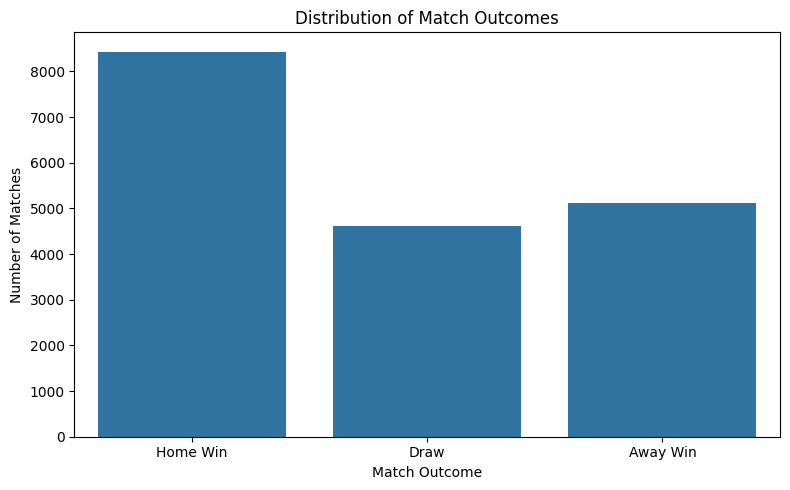

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

order = ["Home Win", "Draw", "Away Win"]

sns.countplot(
    data=eda_df,
    x="target_outcome",
    order=order
)

plt.title("Distribution of Match Outcomes")
plt.xlabel("Match Outcome")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

Statistical Summary

In [31]:
display(
    eda_df[
        ["home_team_goal", "away_team_goal",
         "total_goals", "goal_difference"]
    ].describe()
)

,home_team_goal,away_team_goal,total_goals,goal_difference
count,18183.000000,18183.000000,18183.000000,18183.000000
mean,1.548204,1.151130,2.699335,0.397074
std,1.295421,1.139019,1.675975,1.772589
min,0.000000,0.000000,0.000000,-8.000000
25%,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,1.000000,3.000000,0.000000
75%,2.000000,2.000000,4.000000,1.000000
max,10.000000,8.000000,12.000000,10.000000


Distribution of Goals

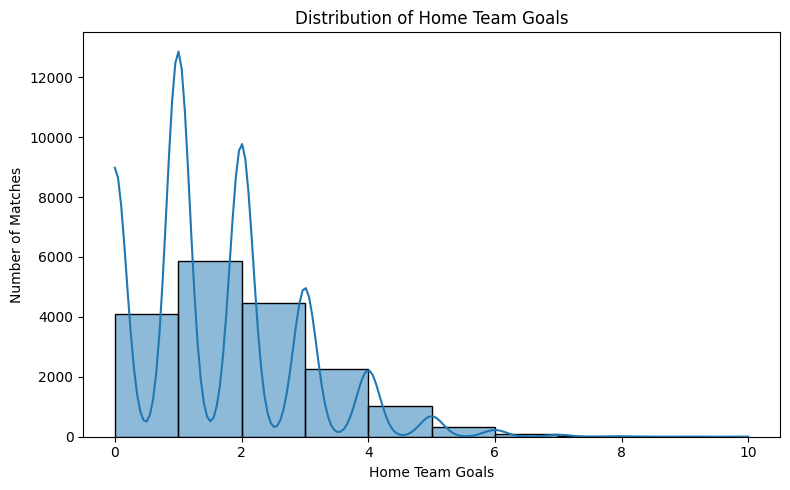

In [32]:
plt.figure(figsize=(8, 5))

sns.histplot(
    eda_df["home_team_goal"],
    bins=10,
    kde=True
)

plt.title("Distribution of Home Team Goals")
plt.xlabel("Home Team Goals")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

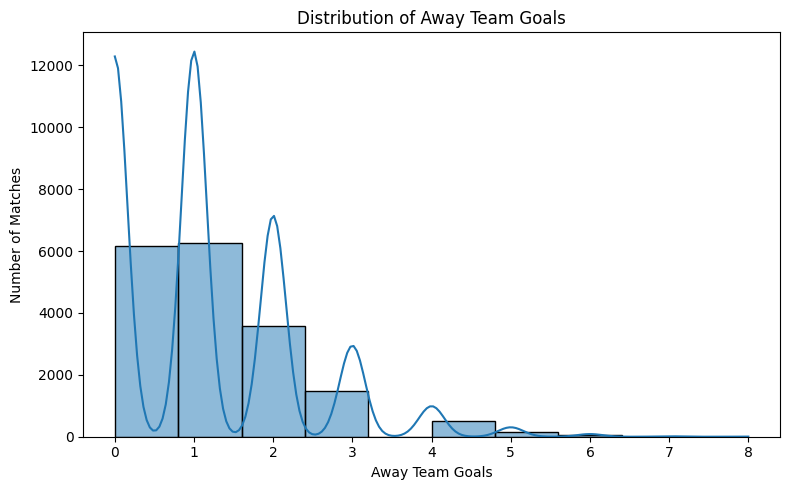

In [33]:
plt.figure(figsize=(8, 5))

sns.histplot(
    eda_df["away_team_goal"],
    bins=10,
    kde=True
)

plt.title("Distribution of Away Team Goals")
plt.xlabel("Away Team Goals")
plt.ylabel("Number of Matches")
plt.tight_layout()
plt.show()

Average Goals for Each Outcome

In [34]:
goal_summary = (
    eda_df
    .groupby("target_outcome")
    .agg(
        Average_Home_Goals=("home_team_goal", "mean"),
        Average_Away_Goals=("away_team_goal", "mean"),
        Average_Total_Goals=("total_goals", "mean"),
        Average_Goal_Difference=("goal_difference", "mean")
    )
    .reindex(["Home Win", "Draw", "Away Win"])
)

display(goal_summary.round(2))

,Average_Home_Goals,Average_Away_Goals,Average_Total_Goals,Average_Goal_Difference
target_outcome,,,,
Home Win,2.44,0.54,2.98,1.89
Draw,0.98,0.98,1.97,0.00
Away Win,0.60,2.30,2.90,-1.71


League Outcome Percentage

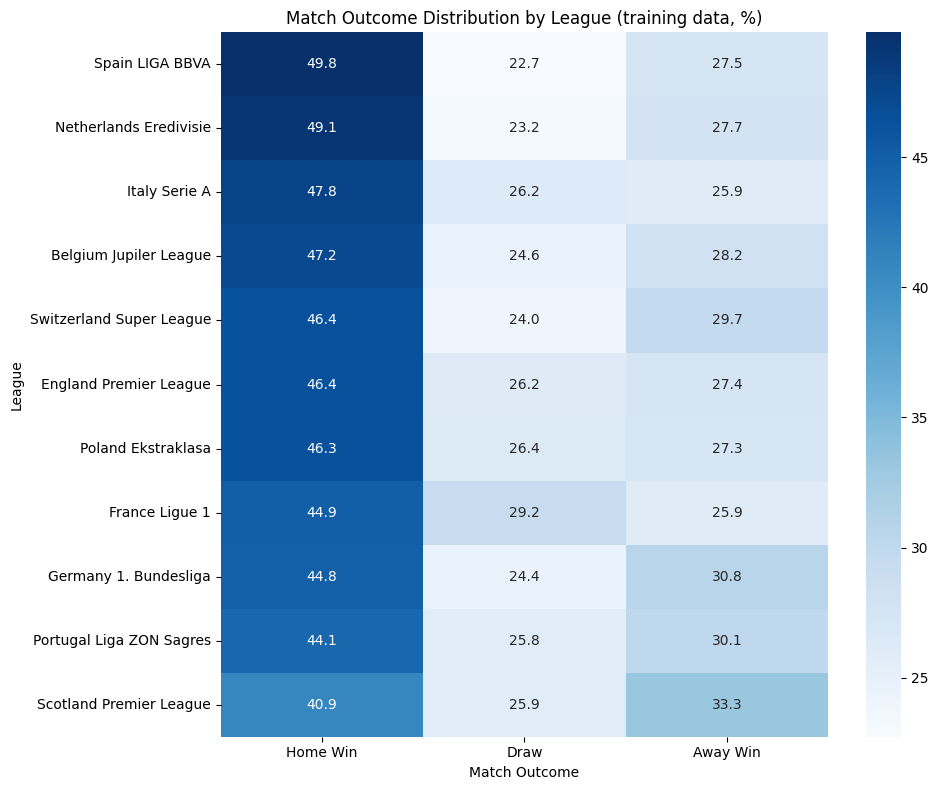

In [35]:
league_outcomes = pd.crosstab(
    eda_df["league_name"],
    eda_df["target_outcome"],
    normalize="index"
) * 100

league_outcomes = league_outcomes[
    ["Home Win", "Draw", "Away Win"]
]

league_outcomes = league_outcomes.sort_values("Home Win", ascending=False)

plt.figure(figsize=(10, 8))

sns.heatmap(league_outcomes, annot=True, fmt=".1f", cmap="Blues")

plt.title("Match Outcome Distribution by League (training data, %)")
plt.xlabel("Match Outcome")
plt.ylabel("League")
plt.tight_layout()
plt.show()

Top Teams by Number of Matches

In [36]:
home_teams = (
    eda_df["home_team"]
    .value_counts()
    .rename("Home Matches")
)

away_teams = (
    eda_df["away_team"]
    .value_counts()
    .rename("Away Matches")
)

team_match_counts = pd.concat(
    [home_teams, away_teams],
    axis=1
).fillna(0)

team_match_counts["Total Matches"] = (
    team_match_counts["Home Matches"] +
    team_match_counts["Away Matches"]
)

display(
    team_match_counts
    .sort_values("Total Matches", ascending=False)
    .head(20)
)

,Home Matches,Away Matches,Total Matches
Polonia Bytom,115,116,231
Arsenal,107,108,215
Kilmarnock,109,106,215
Fulham,107,108,215
Manchester City,107,108,215
St. Mirren,107,108,215
Everton,107,108,215
Stoke City,107,108,215
Chelsea,108,107,215
Manchester United,108,107,215


Goal Difference by Outcome

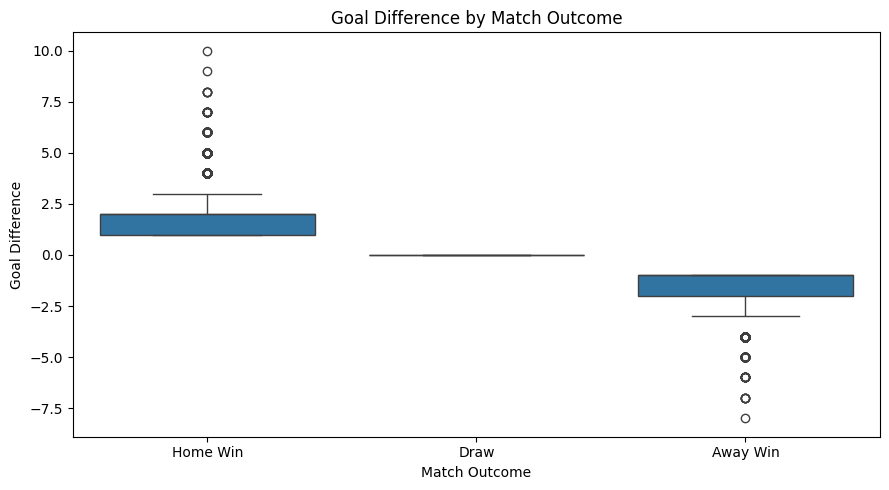

In [37]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=eda_df,
    x="target_outcome",
    y="goal_difference",
    order=["Home Win", "Draw", "Away Win"]
)

plt.title("Goal Difference by Match Outcome")
plt.xlabel("Match Outcome")
plt.ylabel("Goal Difference")
plt.tight_layout()
plt.show()

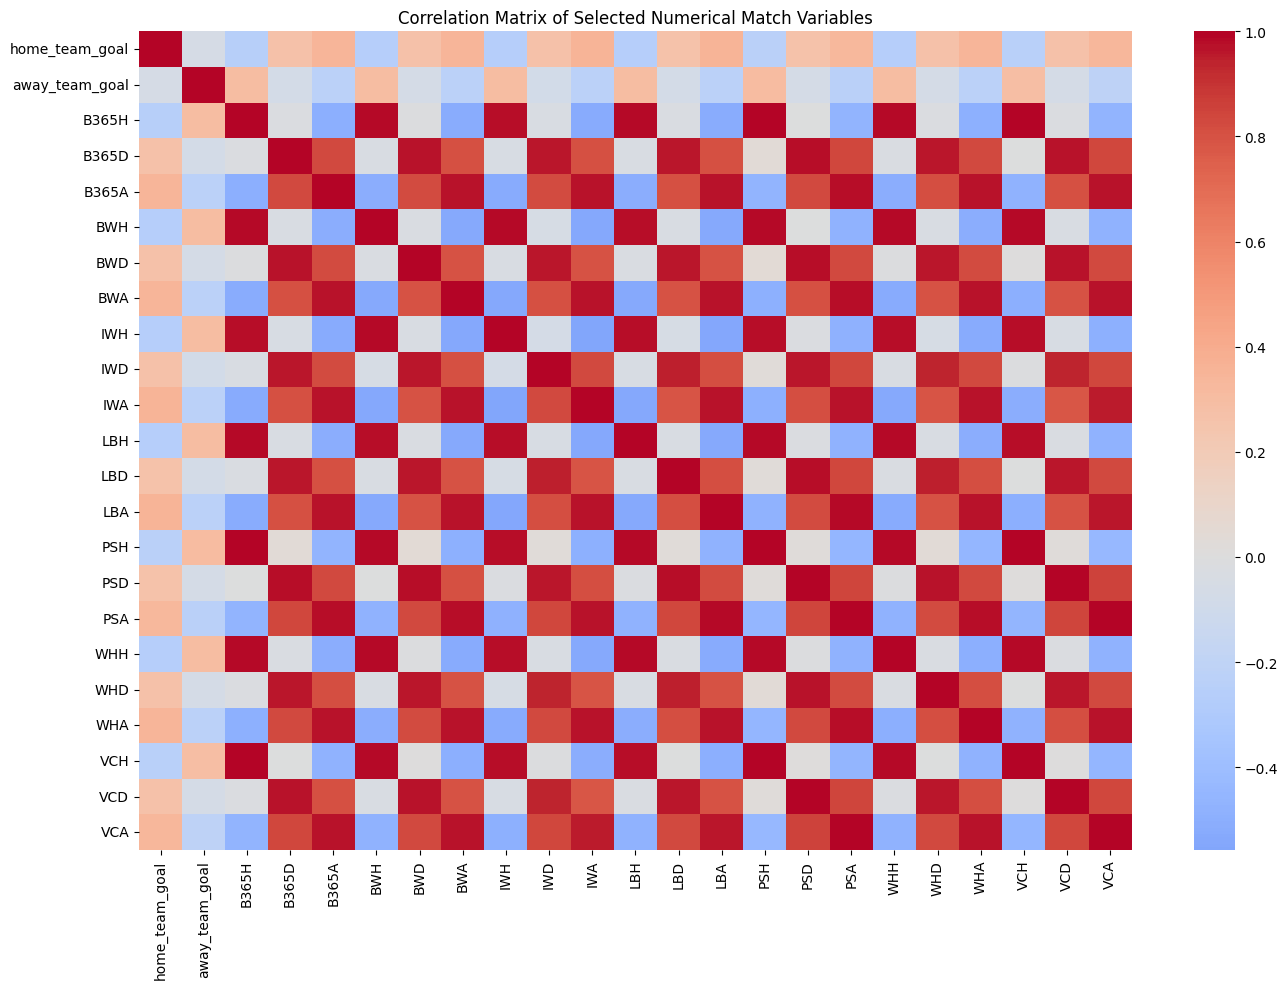

In [38]:
eda_numeric = eda_df[
    [
        "home_team_goal",
        "away_team_goal",
        "B365H",
        "B365D",
        "B365A",
        "BWH",
        "BWD",
        "BWA",
        "IWH",
        "IWD",
        "IWA",
        "LBH",
        "LBD",
        "LBA",
        "PSH",
        "PSD",
        "PSA",
        "WHH",
        "WHD",
        "WHA",
        "VCH",
        "VCD",
        "VCA"
    ]
].copy()

corr_matrix = eda_numeric.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Selected Numerical Match Variables")
plt.tight_layout()
plt.show()

In [39]:
eda_summary = pd.DataFrame({
    "Measure": [
        "Total Matches",
        "Total Leagues",
        "Total Teams",
        "Earliest Match",
        "Latest Match",
        "Home Win %",
        "Draw %",
        "Away Win %",
        "Average Home Goals",
        "Average Away Goals",
        "Average Total Goals"
    ],
    "Value": [
        len(match_clean),
        match_clean["league_name"].nunique(),
        len(
            set(match_clean["home_team"].dropna()) |
            set(match_clean["away_team"].dropna())
        ),
        match_clean["date"].min(),
        match_clean["date"].max(),
        (match_clean["target_outcome"] == "Home Win").mean() * 100,
        (match_clean["target_outcome"] == "Draw").mean() * 100,
        (match_clean["target_outcome"] == "Away Win").mean() * 100,
        match_clean["home_team_goal"].mean(),
        match_clean["away_team_goal"].mean(),
        (match_clean["home_team_goal"] + match_clean["away_team_goal"]).mean()
    ]
})

display(eda_summary)

,Measure,Value
0,Total Matches,25979
1,Total Leagues,11
2,Total Teams,296
3,Earliest Match,2008-07-18 00:00:00
4,Latest Match,2016-05-25 00:00:00
5,Home Win %,45.871666
6,Draw %,25.389738
7,Away Win %,28.738597
8,Average Home Goals,1.544594
9,Average Away Goals,1.160938


target_outcome,Home Win,Draw,Away Win
season,,,
2008/2009,47.1,25.0,27.9
2009/2010,47.4,25.2,27.4
2010/2011,46.6,25.7,27.6
2011/2012,46.5,25.4,28.1
2012/2013,44.3,26.2,29.5
2013/2014,46.3,24.9,28.9


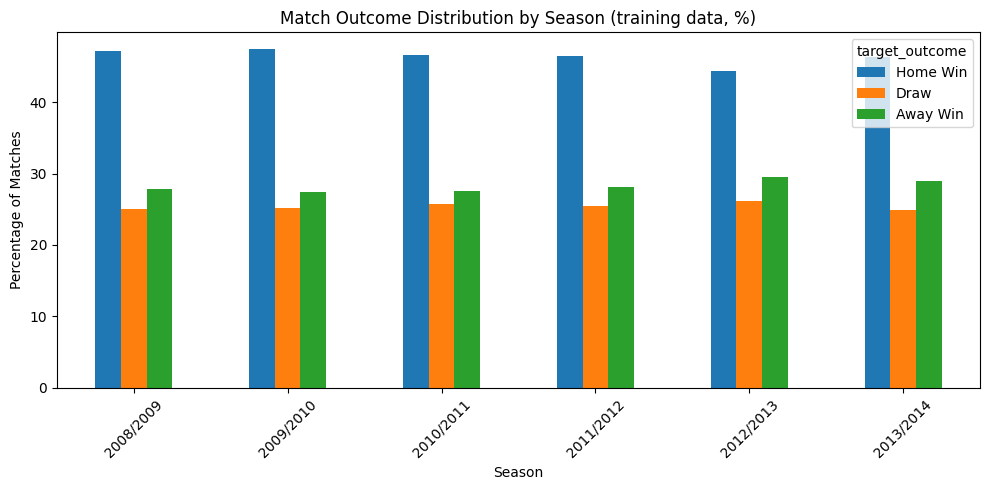

In [40]:
season_outcomes = (pd.crosstab(eda_df["season"], eda_df["target_outcome"], normalize="index")
                   [["Home Win","Draw","Away Win"]] * 100).round(1)

display(season_outcomes)

plt.figure(figsize=(10, 5))
season_outcomes.plot(kind="bar", ax=plt.gca())
plt.title("Match Outcome Distribution by Season (training data, %)")
plt.xlabel("Season")
plt.ylabel("Percentage of Matches")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [41]:
team_home = (eda_df.groupby("home_team")["target_outcome"]
             .agg(matches="count", home_win_rate=lambda s: (s == "Home Win").mean() * 100)
             .query("matches >= 50").sort_values("home_win_rate", ascending=False))

print("Highest home-win rates")
display(team_home.head(10).round(1))
print("Lowest home-win rates")
display(team_home.tail(10).round(1))

Highest home-win rates


,matches,home_win_rate
home_team,,
FC Barcelona,106,87.7
Real Madrid CF,106,85.8
FC Porto,84,83.3
Manchester United,108,80.6
RSC Anderlecht,76,80.3
SL Benfica,83,79.5
Celtic,107,79.4
FC Bayern Munich,95,78.9
Ajax,96,77.1


Lowest home-win rates


,matches,home_win_rate
home_team,,
AC Ajaccio,51,29.4
De Graafschap,51,29.4
Chievo Verona,106,29.2
Wolverhampton Wanderers,57,28.1
Hull City,50,28.0
Racing Santander,76,26.3
St. Mirren,107,25.2
Hamilton Academical FC,57,24.6
S.C. Olhanense,70,24.3


In [42]:
eda_insight_log = pd.DataFrame({
    "Analysis": [
        "Overall outcome distribution",
        "Outcome distribution by season",
        "Home vs away goals",
        "League-level outcome patterns",
        "Team home-win rates",
        "Missing-value analysis",
        "Chronological split"
    ],
    "Purpose": [
        "Assess target class balance",
        "Identify changes in outcome patterns over time",
        "Investigate scoring and possible home advantage",
        "Compare outcome patterns across competitions",
        "Identify differences in team home performance",
        "Identify variables requiring preprocessing",
        "Prevent future information from entering training"
    ],
    "Finding": [""] * 7,   # filled below from real numbers
    "ML_Implication": [
        "Choose suitable evaluation metrics and assess class imbalance",
        "Consider temporal variation during evaluation",
        "Consider relevant pre-match features",
        "League may be useful as a contextual feature",
        "Team identity/performance may contain predictive information",
        "Preprocessing must handle missing values",
        "Provides a more realistic validation strategy"
    ]
})

vc = eda_df["target_outcome"].value_counts(normalize=True) * 100
league_home = (pd.crosstab(eda_df["league_name"], eda_df["target_outcome"], normalize="index")["Home Win"] * 100)
miss = match_df.isnull().mean() * 100
odds_miss = miss[[c for c in miss.index if c.startswith(ODDS_PREFIX)]]

findings = [
    f"Home Win {vc['Home Win']:.1f}%, Draw {vc['Draw']:.1f}%, Away Win {vc['Away Win']:.1f}% (imbalanced; majority baseline ≈ {vc.max():.1f}%)",
    f"Home-win share ranges from {season_outcomes['Home Win'].min():.1f}% to {season_outcomes['Home Win'].max():.1f}% across seasons",
    f"Home teams score {eda_df['home_team_goal'].mean():.2f} goals vs {eda_df['away_team_goal'].mean():.2f} for away teams (home advantage)",
    f"Home-win share ranges from {league_home.min():.1f}% ({league_home.idxmin()}) to {league_home.max():.1f}% ({league_home.idxmax()})",
    f"Home-win rate ranges from {team_home['home_win_rate'].min():.1f}% to {team_home['home_win_rate'].max():.1f}% across teams",
    f"{(miss > 0).sum()} Match columns have missing values; odds columns up to {odds_miss.max():.1f}% missing",
    "Training uses earlier matches and testing uses later matches",
]
eda_insight_log["Finding"] = findings
display(eda_insight_log)

,Analysis,Purpose,Finding,ML_Implication
0,Overall outcome distribution,Assess target class balance,"Home Win 46.4%, Draw 25.4%, Away Win 28.2% (im...",Choose suitable evaluation metrics and assess ...
1,Outcome distribution by season,Identify changes in outcome patterns over time,Home-win share ranges from 44.3% to 47.4% acro...,Consider temporal variation during evaluation
2,Home vs away goals,Investigate scoring and possible home advantage,Home teams score 1.55 goals vs 1.15 for away t...,Consider relevant pre-match features
3,League-level outcome patterns,Compare outcome patterns across competitions,Home-win share ranges from 40.9% (Scotland Pre...,League may be useful as a contextual feature
4,Team home-win rates,Identify differences in team home performance,Home-win rate ranges from 23.6% to 87.7% acros...,Team identity/performance may contain predicti...
5,Missing-value analysis,Identify variables requiring preprocessing,104 Match columns have missing values; odds co...,Preprocessing must handle missing values
6,Chronological split,Prevent future information from entering training,Training uses earlier matches and testing uses...,Provides a more realistic validation strategy
